# 0. Getting setup

In [59]:
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12 or int(torch.__version__.split(".")[0]) == 2, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

torch version: 2.11.0+cu128
torchvision version: 0.26.0+cu128


In [60]:
# Continue with regular imports

import math

import random

import sys

from collections import Counter

from pathlib import Path



import matplotlib.pyplot as plt

import torch

import torchvision

from torch import nn

from torch.utils.data import DataLoader, Subset

from torchvision import datasets, transforms



# Use the project helper locally. Colab only receives this notebook, so provide

# the same implementation when the repository's src directory is unavailable.

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":

    PROJECT_ROOT = PROJECT_ROOT.parent



if (PROJECT_ROOT / "src").is_dir():

    if str(PROJECT_ROOT) not in sys.path:

        sys.path.insert(0, str(PROJECT_ROOT))

    from src.data_setup import create_percentage_dataloaders

else:

    def _stratified_subset_indices(targets, percentage, seed):

        indices_by_class = {}

        for index, target in enumerate(targets):

            indices_by_class.setdefault(target, []).append(index)



        selected_indices = []

        for target in sorted(indices_by_class):

            class_indices = indices_by_class[target]

            random.Random(seed + target).shuffle(class_indices)

            sample_count = max(1, math.ceil(len(class_indices) * percentage / 100))

            selected_indices.extend(class_indices[:sample_count])



        return selected_indices



    def create_percentage_dataloaders(

        train_dir,

        test_dir,

        transform,

        batch_size,

        train_percentage=100,

        seed=42,

        num_workers=0,

    ):

        if not 0 < train_percentage <= 100:

            raise ValueError("train_percentage must be greater than 0 and at most 100")

        if batch_size < 1:

            raise ValueError("batch_size must be at least 1")



        full_train_dataset = datasets.ImageFolder(train_dir, transform=transform)

        test_dataset = datasets.ImageFolder(test_dir, transform=transform)

        selected_indices = _stratified_subset_indices(

            full_train_dataset.targets,

            percentage=train_percentage,

            seed=seed,

        )

        train_dataset = Subset(full_train_dataset, selected_indices)



        generator = torch.Generator().manual_seed(seed)

        loader_options = {

            "batch_size": batch_size,

            "num_workers": num_workers,

            "pin_memory": torch.cuda.is_available(),

        }

        train_dataloader = DataLoader(

            train_dataset,

            shuffle=True,

            generator=generator,

            **loader_options,

        )

        test_dataloader = DataLoader(test_dataset, shuffle=False, **loader_options)



        selected_targets = [full_train_dataset.targets[index] for index in selected_indices]

        class_counts = Counter(selected_targets)

        count_summary = ", ".join(

            f"{class_name}={class_counts[class_index]}"

            for class_index, class_name in enumerate(full_train_dataset.classes)

        )

        print(

            f"Training with {len(train_dataset)}/{len(full_train_dataset)} images "

            f"({train_percentage:g}% requested): {count_summary}"

        )

        print(f"Evaluating with all {len(test_dataset)} test images")



        return train_dataloader, test_dataloader, full_train_dataset.classes



# Try to get torchinfo, install it if it doesn't work

try:

    from torchinfo import summary

except ImportError:

    print("[INFO] Couldn't find torchinfo... installing it.")

    !pip install -q torchinfo

    from torchinfo import summary



# Try to import the going_modular training helpers, download them if needed

try:

    from going_modular.going_modular import engine

    from helper_functions import download_data, set_seeds, plot_loss_curves

except ImportError:

    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")

    !git clone https://github.com/mrdbourke/pytorch-deep-learning

    !mv pytorch-deep-learning/going_modular .

    !mv pytorch-deep-learning/helper_functions.py .

    !rm -rf pytorch-deep-learning

    from going_modular.going_modular import engine

    from helper_functions import download_data, set_seeds, plot_loss_curves

In [61]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [62]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

# 1. Load the prepared PickSense dataset

This notebook does **not** download anything. It expects the dataset to already
exist on Google Drive. If it is missing, run **`00_download_prepare_data.ipynb`** first.

In [63]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/PickSense")
DATA_DIR = PROJECT_DIR / "data" / "picksense_mini"

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR  = DATA_DIR / "test"

In [65]:
# The main notebook NEVER downloads the dataset. If it is missing, stop and tell
# the user to run the preparation notebook first.
if not TRAIN_DIR.exists() or not TEST_DIR.exists():
    raise FileNotFoundError(
        "PickSense dataset was not found. "
        "Run 00_download_prepare_data.ipynb first."
    )

print("\u2705 PickSense dataset found.")
print("Train:", TRAIN_DIR)
print("Test:", TEST_DIR)

✅ PickSense dataset found.
Train: /content/drive/MyDrive/PickSense/data/picksense_mini/train
Test: /content/drive/MyDrive/PickSense/data/picksense_mini/test


In [66]:
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")
CLASSES = ["clear", "partially_occluded", "heavily_occluded"]

def count_images(folder: Path) -> int:
    if not folder.exists():
        return 0
    return sum(1 for p in folder.iterdir()
               if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)

# Verify the expected class folders exist.
for split_dir in (TRAIN_DIR, TEST_DIR):
    for c in CLASSES:
        if not (split_dir / c).exists():
            raise FileNotFoundError(
                f"Missing class folder: {split_dir / c}. "
                "Re-run 00_download_prepare_data.ipynb."
            )

print("\u2705 PickSense dataset ready")
grand_total = 0
for split, sd in [("Train", TRAIN_DIR), ("Test", TEST_DIR)]:
    print("\n" + split + ":")
    split_total = 0
    for c in CLASSES:
        n = count_images(sd / c)
        print(c + ":", n)
        split_total += n
    print("Total:", split_total)
    grand_total += split_total
print("\nTotal images:", grand_total)

# These names are used by the rest of the notebook (transforms, DataLoaders, ...).
train_dir = TRAIN_DIR
test_dir  = TEST_DIR

✅ PickSense dataset ready

Train:
clear: 1000
partially_occluded: 1000
heavily_occluded: 1000
Total: 3000

Test:
clear: 200
partially_occluded: 200
heavily_occluded: 200
Total: 600

Total images: 3600


# 2. Create Datasets and DataLoaders

### 2.1 Prepare transforms for images


In [67]:
# Create image size (from Table 3 in the ViT paper)
IMG_SIZE = 224

import torchvision.transforms as transforms
# Create transform pipeline manually
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
print(f"Manually created transforms: {manual_transforms}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


### 2.2 Choose the training-data percentage and GPU batch size



`TRAIN_PERCENTAGE` controls how much of the prepared training set is used. Use `100` for final training. Lower values such as `10` or `25` are intended only for quick pipeline checks. The complete test set is always used.



`BATCH_SIZE` controls memory per training step. If CUDA reports an out-of-memory error, reduce it from `8` to `4`, `2`, or `1`; do not reduce `TRAIN_PERCENTAGE` to solve a memory error.



The prepared dataset contains 1,000 training and 200 test images per class: 3,000 training images and 600 test images total.

In [68]:
# Train on the full balanced dataset. Reduce only BATCH_SIZE for GPU memory.

TRAIN_PERCENTAGE = 100

BATCH_SIZE = 8

DATA_SEED = 42



train_dataloader, test_dataloader, class_names = create_percentage_dataloaders(

    train_dir=train_dir,

    test_dir=test_dir,

    transform=manual_transforms,

    batch_size=BATCH_SIZE,

    train_percentage=TRAIN_PERCENTAGE,

    seed=DATA_SEED,

    num_workers=2,

)



print(f"Training batches: {len(train_dataloader)}")

print(f"Test batches: {len(test_dataloader)}")

print(f"Classes: {class_names}")

Training with 3000/3000 images (100% requested): clear=1000, heavily_occluded=1000, partially_occluded=1000
Evaluating with all 600 test images
Training batches: 375
Test batches: 75
Classes: ['clear', 'heavily_occluded', 'partially_occluded']


### 2.3 Visualize a single image

In [69]:
# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))

# Get a single image from the batch
image, label = image_batch[0], label_batch[0]

# View the batch shapes
image.shape, label

(torch.Size([3, 224, 224]), tensor(1))

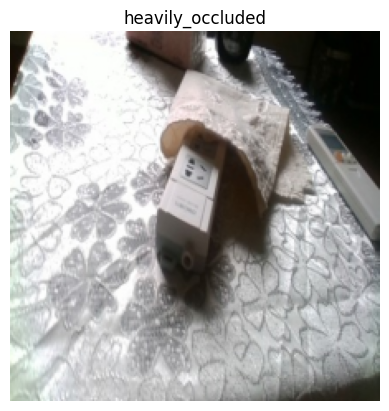

In [70]:
# Plot image with matplotlib
plt.imshow(image.permute(1, 2, 0)) # rearrange image dimensions to suit matplotlib [color_channels, height, width] -> [height, width, color_channels]
plt.title(class_names[label])
plt.axis(False);

# 3. Replicating the ViT paper: an overview

Looking at a whole machine learning paper can be overwhelming, especially if it's a new architecture or model. To make it easier to understand, let's break down the ViT paper into its core components.

* **inputs** - What goes into the model (e.g. images, text, audio, etc.)
* **outputs** - What comes out the model/layer/block? (in this case, i want the model to output classification labels)
* **layers** - Takes an inputs, manipulates it with a function(e.g could be self-attention)
* **blocks** - A collection of layers.
* **model** - A collection of blocks.

### 3.1 ViT overview: pieces of the puzzle

* firgure 1 : Visual overview of the architecture of the Vision Transformer (ViT) model. The model takes an image as input, splits it into patches, and then processes these patches through a series of transformer blocks to produce a final classification output.
* Four equations: math equations which define the functions of each layer/block.
* Table 1/3: different hyperparameters for the architecture/training.
* Text: description of the architecture and training process.

#### Figure 1
 ![](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/images/08-vit-paper-figure-1-architecture-overview.png?raw=true)

* Embedding = learnable representations (startt with random numbers and improve them over time)

## Section 3.1 Vision Transformer (ViT) Equations.

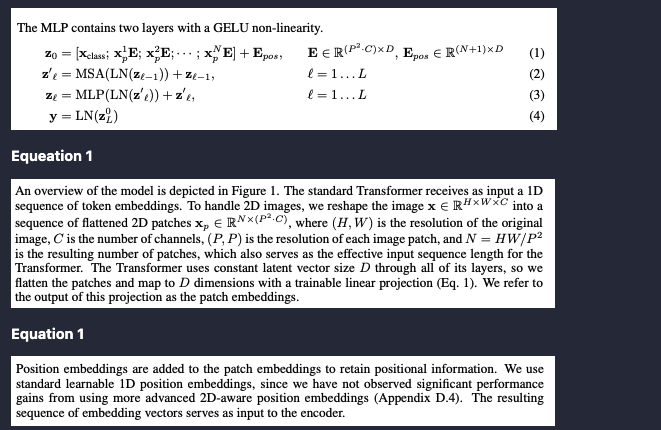



```python
x_input = [class_token, image_patch_1, image_patch_2, image_patch_3...] + [class_token_position, image_patch_1_position, image_patch_2_position, image_patch_3_position...]
```




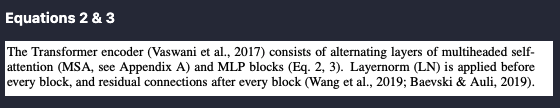


```python
# Equation 2
x_output_MSA_block = MSA_layer(LN_layer(x_input)) + x_input
```


```python
# Equation 3
x_output_MLP_block = MLP_layer(LN_layer(x_output_MSA_block)) + x_output_MSA_block
```



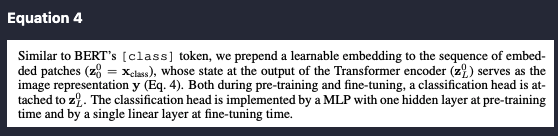

Note: MLP = Multi-Layer Perceptron = a neural network with at least 1 hidden layer.

```python
y = Linear_layer(LN_layer(x_output_MLP_block[0]))
```


### Table 1

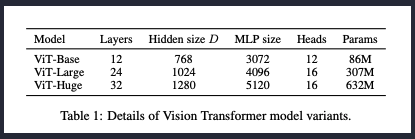


* ViT-Base, ViT-Large and ViT-Huge are all different sizes of the same architecture. The larger the model, the more parameters it has and the more data it needs to train effectively.
* layers - the number of transformer blocks in the model.
* Hidden size $D$ -  the embedding size of the model (the number of features in the input and output of each layer).
* MLP size - the number of neurons in the hidden layer of the MLP block.
* Heads - the number of attention heads in the multi-head self-attention (MSA) block.
* Parameters - the total number of trainable parameters in the model.










# 4. Equation 1: Split data into patches and creating the class, position and patch embedding

Layers = Input image -> Patch embedding -> Class embedding -> Position embedding (input -> function -> output)

What's the input shape?
* Input shape = (224,224,3) -> single image -> (height, width, color channels)

What is the output shape?
* Output shape = (num_patches + 1, embedding_dim) -> sequence of patch embeddings with class token


* Input shape: $H\times{W}\times{C}$ (height x width x color channels)
* Output shape: ${N\times\left(P^{2}\cdot{C}\right)}$

Where:
* H = height of the input image
* W = width of the input image
* C = color channels of the input image
* P = patch size (height and width of each patch)
* N = number of patches = (height * width) / p^2
* D = embedding dimension (the size of the vector representing each patch)



### 4.1 Calculating patch embedding input and output shapes by hand




In [71]:
# Create example values
height = 224 # H ("The training resolution is 224.")
width = 224 # W
color_channels = 3 # C
patch_size = 16 # P

# Calculate N (number of patches)
number_of_patches = int((height * width) / patch_size**2)
print(f"Number of patches (N) with image height (H={height}), width (W={width}) and patch size (P={patch_size}): {number_of_patches}")

Number of patches (N) with image height (H=224), width (W=224) and patch size (P=16): 196


In [72]:
# Input shape (this is the size of a single image)
embedding_layer_input_shape = (height, width, color_channels)

# Output shape
embedding_layer_output_shape = (number_of_patches, patch_size**2 * color_channels)

print(f"Input shape (single 2D image): {embedding_layer_input_shape}")
print(f"Output shape (single 2D image flattened into patches): {embedding_layer_output_shape}")

Input shape (single 2D image): (224, 224, 3)
Output shape (single 2D image flattened into patches): (196, 768)


### 4.2 Turning a single image into patches


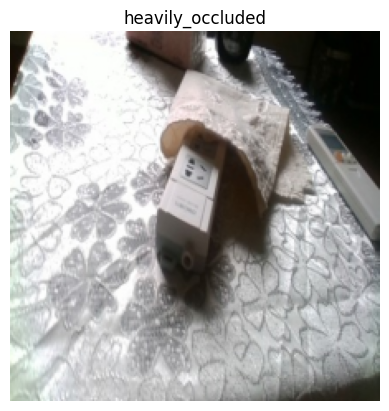

In [73]:
# View single image
plt.imshow(image.permute(1, 2, 0)) # adjust for matplotlib
plt.title(class_names[label])
plt.axis(False);

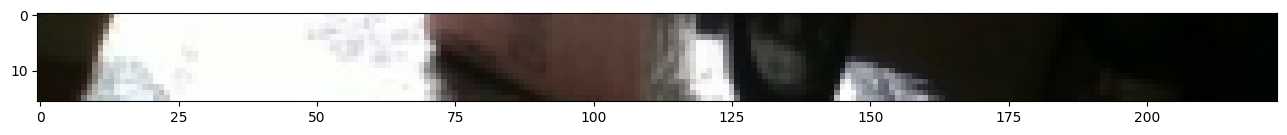

In [74]:
# Change image shape to be compatible with matplotlib (color_channels, height, width) -> (height, width, color_channels)
image_permuted = image.permute(1, 2, 0)

# Index to plot the top row of patched pixels
patch_size = 16
plt.figure(figsize=(patch_size, patch_size))
plt.imshow(image_permuted[:patch_size, :, :]);

In [75]:
image.shape

torch.Size([3, 224, 224])

Number of patches per row: 14.0
Patch size: 16 pixels x 16 pixels


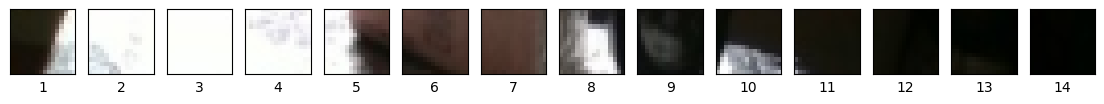

In [76]:
# Setup hyperparameters and make sure img_size and patch_size are compatible
img_size = 224
patch_size = 16
num_patches = img_size/patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size"
print(f"Number of patches per row: {num_patches}\nPatch size: {patch_size} pixels x {patch_size} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows=1,
                        ncols=img_size // patch_size, # one column for each patch
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

# Iterate through number of patches in the top row
for i, patch in enumerate(range(0, img_size, patch_size)):
    axs[i].imshow(image_permuted[:patch_size, patch:patch+patch_size, :]); # keep height index constant, alter the width index
    axs[i].set_xlabel(i+1) # set the label
    axs[i].set_xticks([])
    axs[i].set_yticks([])

Number of patches per row: 14.0        
Number of patches per column: 14.0        
Total patches: 196.0        
Patch size: 16 pixels x 16 pixels


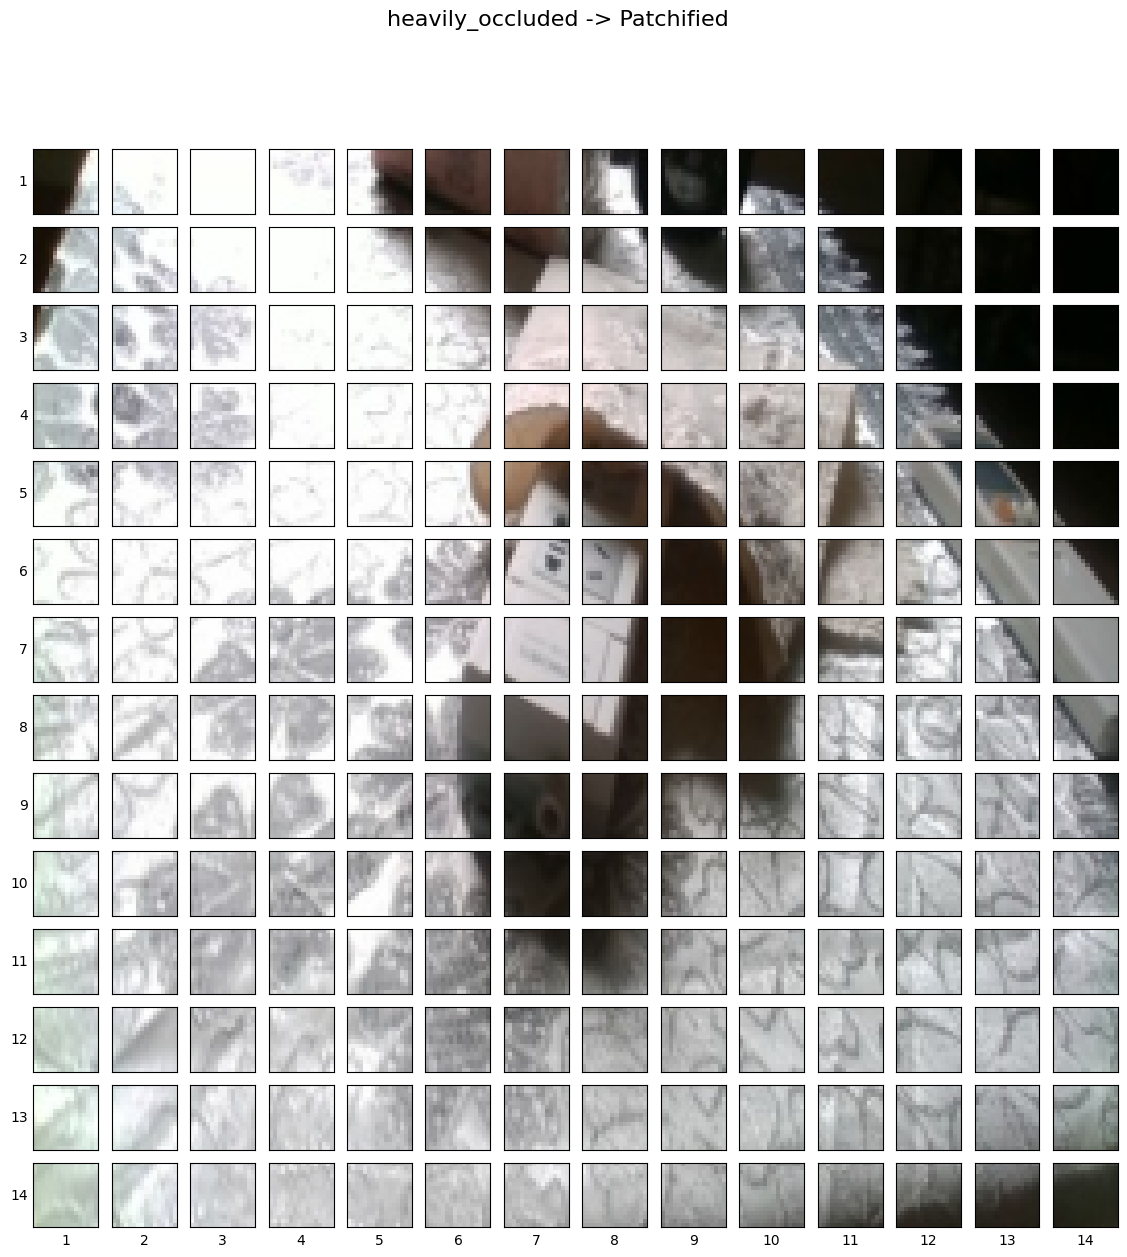

In [77]:
# Setup hyperparameters and make sure img_size and patch_size are compatible
img_size = 224
patch_size = 16
num_patches = img_size/patch_size
assert img_size % patch_size == 0, "Image size must be divisible by patch size"
print(f"Number of patches per row: {num_patches}\
        \nNumber of patches per column: {num_patches}\
        \nTotal patches: {num_patches*num_patches}\
        \nPatch size: {patch_size} pixels x {patch_size} pixels")

# Create a series of subplots
fig, axs = plt.subplots(nrows=img_size // patch_size, # need int not float
                        ncols=img_size // patch_size,
                        figsize=(num_patches, num_patches),
                        sharex=True,
                        sharey=True)

# Loop through height and width of image
for i, patch_height in enumerate(range(0, img_size, patch_size)): # iterate through height
    for j, patch_width in enumerate(range(0, img_size, patch_size)): # iterate through width

        # Plot the permuted image patch (image_permuted -> (Height, Width, Color Channels))
        axs[i, j].imshow(image_permuted[patch_height:patch_height+patch_size, # iterate through height
                                        patch_width:patch_width+patch_size, # iterate through width
                                        :]) # get all color channels

        # Set up label information, remove the ticks for clarity and set labels to outside
        axs[i, j].set_ylabel(i+1,
                             rotation="horizontal",
                             horizontalalignment="right",
                             verticalalignment="center")
        axs[i, j].set_xlabel(j+1)
        axs[i, j].set_xticks([])
        axs[i, j].set_yticks([])
        axs[i, j].label_outer()

# Set a super title
fig.suptitle(f"{class_names[label]} -> Patchified", fontsize=16)
plt.show()

## 4.3 Creating image patches with `torch.nn.Conv2d()`
Perphaps we could creat the image patches and patch embedding in a single step using `torch.nn.Conv2d()` and setting the kernel size and stride parameters to `patch_size`. This would allow us to create the patches and embed them in a single step, rather than having to do it in two separate steps. 


In [78]:
# create conv2d layer to create patches and embed them in a single step
from torch import nn

#set the patch size
patch_size = 16

# Create a conv2d layer with hyperparameters to create patches and embed them in a single step

conv2d = nn.Conv2d(in_channels=3, # color channels
                   out_channels=768, # embedding dimension
                   kernel_size=patch_size, # patch size
                   stride=patch_size, # patch size
                   padding=0) 
conv2d

Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))

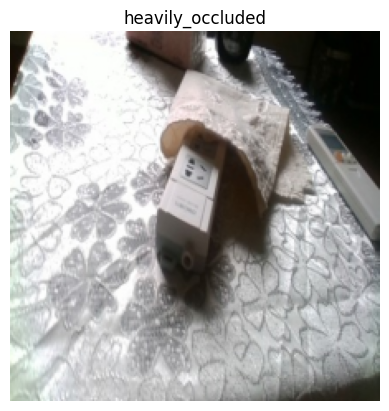

In [79]:
# View single image shape
plt.imshow(image.permute(1, 2, 0)) # adjust for matplotlib
plt.title(class_names[label])
plt.axis(False);

In [80]:
# Pass the image through the convolutional layer.

image_out_of_conv = conv2d(image.unsqueeze(0)) # add batch dimension
print(image_out_of_conv.shape) # (batch_size, embedding_dimension, num_patches_height, num_patches_width)

torch.Size([1, 768, 14, 14])


Now we have passed a single image through the convolutional (`conv2d`) layer, let's check the output shape.

```python
torch.Size([1, 768, 14, 14]) # (batch_size, embedding_dimension, num_patches_height, num_patches_width)
```

In [81]:
image_out_of_conv.requires_grad

True

Showing random convolutional feature maps from indexes: [3, 440, 181, 339, 260]


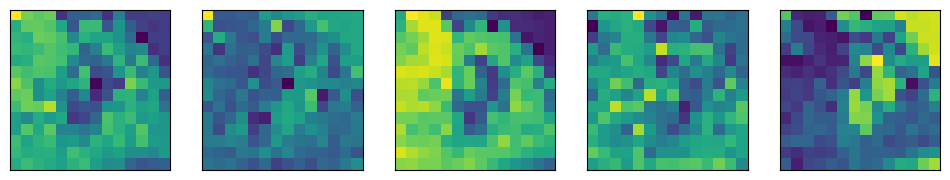

In [82]:
# Plot random 5 convolutional feature maps
import random
random_indexes = random.sample(range(0, 758), k=5) # pick 5 numbers between 0 and the embedding size
print(f"Showing random convolutional feature maps from indexes: {random_indexes}")

# Create plot
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(12, 12))

# Plot random image feature maps
for i, idx in enumerate(random_indexes):
    image_conv_feature_map = image_out_of_conv[:, idx, :, :] # index on the output tensor of the convolutional layer
    axs[i].imshow(image_conv_feature_map.squeeze().detach().numpy())
    axs[i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[]);

In [83]:
# Get a single feature map in tensor form
single_feature_map = image_out_of_conv[:, 0, :, :]
single_feature_map, single_feature_map.requires_grad

(tensor([[[-2.4292e-01, -1.0273e+00, -1.0475e+00, -1.0148e+00, -7.4401e-01,
           -2.1313e-01, -2.8415e-01, -9.1918e-01, -1.4630e-01, -8.3530e-02,
           -1.0722e-01, -4.5918e-02, -1.3484e-02, -2.4015e-03],
          [-3.9589e-01, -7.8564e-01, -1.0122e+00, -1.0480e+00, -1.1530e+00,
           -5.1143e-01, -3.5687e-01, -3.3632e-01, -3.5500e-01, -3.9850e-01,
           -4.1699e-01, -4.5174e-02, -1.9859e-02, -1.2987e-03],
          [-6.9657e-01, -8.3412e-01, -9.2827e-01, -1.0248e+00, -1.0476e+00,
           -1.0317e+00, -7.0369e-01, -8.7292e-01, -7.7584e-01, -8.0846e-01,
           -5.1061e-01, -1.0658e-01, -1.5812e-02,  1.7029e-04],
          [-6.6731e-01, -5.8723e-01, -8.7114e-01, -1.0225e+00, -1.0490e+00,
           -1.0224e+00, -7.7008e-01, -6.7459e-01, -8.1613e-01, -6.3573e-01,
           -7.7198e-01, -6.0074e-01, -5.7322e-02, -1.4809e-02],
          [-9.4047e-01, -1.0248e+00, -9.4879e-01, -1.0147e+00, -1.0279e+00,
           -1.1165e+00, -6.6041e-01, -1.6424e-01, -1.9889e-0

### 4.4 Flattening the patch embeddings with `torch.flatten()`
Right now there are a series of convolutional feature maps (patch embeddings) that I want to flatten into a sequence of patch embedding to satisfy the input criteria of the ViT Transformer Encoder.


In [84]:
# Current tensor shape
print(f"Current tensor shape: {image_out_of_conv.shape} -> [batch, embedding_dim, feature_map_height, feature_map_width]")

Current tensor shape: torch.Size([1, 768, 14, 14]) -> [batch, embedding_dim, feature_map_height, feature_map_width]


Want : (batch_size, num_patches, embedding_dimension) = (1, 196, 768)

In [85]:
# Create flatten layer
flatten = nn.Flatten(start_dim=2, # flatten feature_map_height (dimension 2)
                     end_dim=3) # flatten feature_map_width (dimension 3)
flatten(image_out_of_conv).shape

torch.Size([1, 768, 196])

Original image shape: torch.Size([3, 224, 224])
Image feature map shape: torch.Size([1, 768, 14, 14])
Flattened image feature map shape: torch.Size([1, 768, 196])


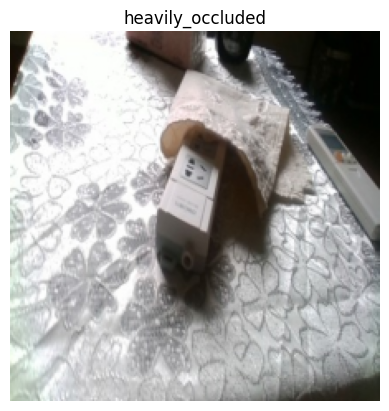

In [86]:
# 1. View single image
plt.imshow(image.permute(1, 2, 0)) # adjust for matplotlib
plt.title(class_names[label])
plt.axis(False);
print(f"Original image shape: {image.shape}")

# 2. Turn image into feature maps
image_out_of_conv = conv2d(image.unsqueeze(0)) # add batch dimension to avoid shape errors
print(f"Image feature map shape: {image_out_of_conv.shape}")

# 3. Flatten the feature maps
image_out_of_conv_flattened = flatten(image_out_of_conv)
print(f"Flattened image feature map shape: {image_out_of_conv_flattened.shape}")

In [87]:
# Get flattened image patch embeddings in right shape
image_out_of_conv_flattened_reshaped = image_out_of_conv_flattened.permute(0, 2, 1) # [batch_size, P^2•C, N] -> [batch_size, N, P^2•C]
print(f"Patch embedding sequence shape: {image_out_of_conv_flattened_reshaped.shape} -> [batch_size, num_patches, embedding_size]")

Patch embedding sequence shape: torch.Size([1, 196, 768]) -> [batch_size, num_patches, embedding_size]


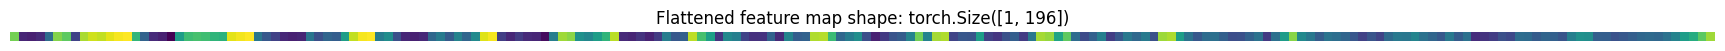

In [88]:
# Get a single flattened feature map
single_flattened_feature_map = image_out_of_conv_flattened.permute(0, 2, 1)[:, :, 0] # index: (batch_size, number_of_patches, embedding_dimension)

# Plot the flattened feature map visually
plt.figure(figsize=(22, 22))
plt.imshow(single_flattened_feature_map.detach().numpy())
plt.title(f"Flattened feature map shape: {single_flattened_feature_map.shape}")
plt.axis(False);

In [89]:
# See the flattened feature map as a tensor
single_flattened_feature_map, single_flattened_feature_map.requires_grad, single_flattened_feature_map.shape

(tensor([[-2.4292e-01, -1.0273e+00, -1.0475e+00, -1.0148e+00, -7.4401e-01,
          -2.1313e-01, -2.8415e-01, -9.1918e-01, -1.4630e-01, -8.3530e-02,
          -1.0722e-01, -4.5918e-02, -1.3484e-02, -2.4015e-03, -3.9589e-01,
          -7.8564e-01, -1.0122e+00, -1.0480e+00, -1.1530e+00, -5.1143e-01,
          -3.5687e-01, -3.3632e-01, -3.5500e-01, -3.9850e-01, -4.1699e-01,
          -4.5174e-02, -1.9859e-02, -1.2987e-03, -6.9657e-01, -8.3412e-01,
          -9.2827e-01, -1.0248e+00, -1.0476e+00, -1.0317e+00, -7.0369e-01,
          -8.7292e-01, -7.7584e-01, -8.0846e-01, -5.1061e-01, -1.0658e-01,
          -1.5812e-02,  1.7029e-04, -6.6731e-01, -5.8723e-01, -8.7114e-01,
          -1.0225e+00, -1.0490e+00, -1.0224e+00, -7.7008e-01, -6.7459e-01,
          -8.1613e-01, -6.3573e-01, -7.7198e-01, -6.0074e-01, -5.7322e-02,
          -1.4809e-02, -9.4047e-01, -1.0248e+00, -9.4879e-01, -1.0147e+00,
          -1.0279e+00, -1.1165e+00, -6.6041e-01, -1.6424e-01, -1.9889e-01,
          -5.6967e-01, -6

## 4.5 Turning the ViT patch embedding layer into a PyTorch module

* 1) Create a class called `PatchEmbedding` 
* 2) Initialize with appropriate hyperparameters, such as channel size, patch size and embedding dimension.
* 3) Create a layer to turn an image into patches using `nn.Conv2d()` (just like in 4.3 above).
* 4) Create a layer to flatten the patch feature maps into a single dimension (just like in 4.4 above).
* 5) Define a `forward()` method to take an input and pass it through the layers created in 3 and 4.
* 6) Make sure the output shape reflects the required output shape of the ViT architecture (${N \times\left(P^{2} \cdot C\right)}$).

In [90]:
class PatchEmbedding(nn.Module):

    """Turns a batch of 2D images into patch embedding sequences."""



    def __init__(self, in_channels=3, patch_size=16, embedding_dim=768):

        super().__init__()

        self.patch_size = patch_size

        self.patcher = nn.Conv2d(

            in_channels=in_channels,

            out_channels=embedding_dim,

            kernel_size=patch_size,

            stride=patch_size,

            padding=0,

        )

        self.flatten = nn.Flatten(start_dim=2, end_dim=3)



    def forward(self, x):

        image_height, image_width = x.shape[-2:]

        if image_height % self.patch_size != 0 or image_width % self.patch_size != 0:

            raise ValueError(

                f"Input height and width must be divisible by patch size "

                f"{self.patch_size}; received {image_height}x{image_width}."

            )



        x = self.patcher(x)

        x = self.flatten(x)

        return x.permute(0, 2, 1)

In [91]:
set_seeds()

# Create a instance of patch embedding layer
patchify = PatchEmbedding(in_channels=3,
                        patch_size=16,
                        embedding_dim=768)
#Pass a single image through the patch embedding layer
print(f"Input image shape: {image.unsqueeze(0).shape}")
patch_embedded_image = patchify(image.unsqueeze(0)) # add an extra batch dimension to the image
print(f"Output patch embedding shape: {patch_embedded_image.shape} -> [batch_size, num_patches, embedding_dimension]")

Input image shape: torch.Size([1, 3, 224, 224])
Output patch embedding shape: torch.Size([1, 196, 768]) -> [batch_size, num_patches, embedding_dimension]


In [92]:
# Create random input sizes
random_input_image = (1, 3, 224, 224)
random_input_image_error = (1, 3, 250, 250) # will error because image size is incompatible with patch_size

# # Get a summary of the input and outputs of PatchEmbedding (uncomment for full output)
summary(PatchEmbedding(),
        input_size=random_input_image, # try swapping this for "random_input_image_error"
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
PatchEmbedding (PatchEmbedding)          [1, 3, 224, 224]     [1, 196, 768]        --                   True
├─Conv2d (patcher)                       [1, 3, 224, 224]     [1, 768, 14, 14]     590,592              True
├─Flatten (flatten)                      [1, 768, 14, 14]     [1, 768, 196]        --                   --
Total params: 590,592
Trainable params: 590,592
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 115.76
Input size (MB): 0.60
Forward/backward pass size (MB): 1.20
Params size (MB): 2.36
Estimated Total Size (MB): 4.17

### 4.6 Creating the class token embedding

Want to : prepend a learnable class token embedding to the sequence of patch embeddings. This class token will be used to represent the entire image and will be the input to the final classification layer.



In [93]:
patch_embedded_image

tensor([[[-0.6051,  0.4157, -0.1346,  ...,  0.1833, -0.2712, -0.0702],
         [-1.0377,  0.3328, -0.2695,  ...,  0.7966, -0.4941,  0.2989],
         [-1.0314,  0.2866, -0.2928,  ...,  0.7868, -0.4686,  0.3648],
         ...,
         [-0.3554,  0.0691,  0.0929,  ...,  0.2357, -0.2910,  0.1387],
         [-0.2382,  0.0351,  0.0460,  ...,  0.2204, -0.2337,  0.0630],
         [-0.1307,  0.0027, -0.0402,  ...,  0.1706, -0.1441,  0.0639]]],
       grad_fn=<PermuteBackward0>)

In [94]:
# View the patch embedding and patch embedding shape
print(patch_embedded_image)
print(f"Patch embedding shape: {patch_embedded_image.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[-0.6051,  0.4157, -0.1346,  ...,  0.1833, -0.2712, -0.0702],
         [-1.0377,  0.3328, -0.2695,  ...,  0.7966, -0.4941,  0.2989],
         [-1.0314,  0.2866, -0.2928,  ...,  0.7868, -0.4686,  0.3648],
         ...,
         [-0.3554,  0.0691,  0.0929,  ...,  0.2357, -0.2910,  0.1387],
         [-0.2382,  0.0351,  0.0460,  ...,  0.2204, -0.2337,  0.0630],
         [-0.1307,  0.0027, -0.0402,  ...,  0.1706, -0.1441,  0.0639]]],
       grad_fn=<PermuteBackward0>)
Patch embedding shape: torch.Size([1, 196, 768]) -> [batch_size, number_of_patches, embedding_dimension]


In [95]:
# Get the batch size and embedding dimension
batch_size = patch_embedded_image.shape[0]
embedding_dimension = patch_embedded_image.shape[-1]

# Create the class token embedding as a learnable parameter that shares the same size as the embedding dimension (D)
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension), # [batch_size, number_of_tokens, embedding_dimension]
                           requires_grad=True) # make sure the embedding is learnable

# Show the first 10 examples of the class_token
print(class_token[:, :, :10])

# Print the class_token shape
print(f"Class token shape: {class_token.shape} -> [batch_size, number_of_tokens, embedding_dimension]")

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Class token shape: torch.Size([1, 1, 768]) -> [batch_size, number_of_tokens, embedding_dimension]


In [96]:
# Add the class token embedding to the front of the patch embedding
patch_embedded_image_with_class_embedding = torch.cat((class_token, patch_embedded_image),
                                                      dim=1) # concat on first dimension

# Print the sequence of patch embeddings with the prepended class token embedding
print(patch_embedded_image_with_class_embedding)
print(f"Sequence of patch embeddings with class token prepended shape: {patch_embedded_image_with_class_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
         [-0.6051,  0.4157, -0.1346,  ...,  0.1833, -0.2712, -0.0702],
         [-1.0377,  0.3328, -0.2695,  ...,  0.7966, -0.4941,  0.2989],
         ...,
         [-0.3554,  0.0691,  0.0929,  ...,  0.2357, -0.2910,  0.1387],
         [-0.2382,  0.0351,  0.0460,  ...,  0.2204, -0.2337,  0.0630],
         [-0.1307,  0.0027, -0.0402,  ...,  0.1706, -0.1441,  0.0639]]],
       grad_fn=<CatBackward0>)
Sequence of patch embeddings with class token prepended shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


In [97]:
random_image_tensor = torch.rand((1, 3, 224, 224)) # [batch_size, color_channels, height, width]
rand_image_tensor_bad = torch.randn(1,3, 250, 250) # [batch_size, color_channels, height, width] - will error because image size is incompatible with patch_size

patchify(random_image_tensor)

tensor([[[-0.4380,  0.1618, -0.4255,  ...,  0.2490, -0.5111,  0.1327],
         [-0.4437, -0.0274, -0.1842,  ...,  0.2421, -0.1996,  0.1288],
         [-0.3306,  0.0647, -0.2855,  ...,  0.9124, -0.2679,  0.0543],
         ...,
         [-0.3052,  0.1963, -0.1544,  ..., -0.0517, -0.3107, -0.0465],
         [-0.6273,  0.2237,  0.0456,  ...,  0.3801, -0.3411, -0.0097],
         [-0.4417,  0.3767,  0.0755,  ...,  0.4713, -0.2320,  0.0277]]],
       grad_fn=<PermuteBackward0>)

### Creating a position embedding

Want to: Create a series of 1D learnable position embeddings to add to the sequence of patch embeddings. This will allow the model to understand the spatial relationships between the patches in the image.



In [98]:
# View the sequence of patch embeddings with the prepended class token embedding
# View the sequence of patch embeddings with the prepended class embedding
patch_embedded_image_with_class_embedding, patch_embedded_image_with_class_embedding.shape


(tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
          [-0.6051,  0.4157, -0.1346,  ...,  0.1833, -0.2712, -0.0702],
          [-1.0377,  0.3328, -0.2695,  ...,  0.7966, -0.4941,  0.2989],
          ...,
          [-0.3554,  0.0691,  0.0929,  ...,  0.2357, -0.2910,  0.1387],
          [-0.2382,  0.0351,  0.0460,  ...,  0.2204, -0.2337,  0.0630],
          [-0.1307,  0.0027, -0.0402,  ...,  0.1706, -0.1441,  0.0639]]],
        grad_fn=<CatBackward0>),
 torch.Size([1, 197, 768]))

In [99]:
# Calculate N (number of patches)
number_of_patches = int((height * width) / patch_size**2)

# Get embedding dimension
embedding_dimension = patch_embedded_image_with_class_embedding.shape[2]

# Create the learnable 1D position embedding
position_embedding = nn.Parameter(torch.ones(1,
                                             number_of_patches+1,
                                             embedding_dimension),
                                  requires_grad=True) # make sure it's learnable

# Show the first 10 sequences and 10 position embedding values and check the shape of the position embedding
print(position_embedding[:, :10, :10])
print(f"Position embedding shape: {position_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Position embedding shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


In [100]:
# Add the position embedding to the patch and class token embedding
patch_and_position_embedding = patch_embedded_image_with_class_embedding + position_embedding
print(patch_and_position_embedding)
print(f"Patch embeddings, class token prepended and positional embeddings added shape: {patch_and_position_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[ 2.0000,  2.0000,  2.0000,  ...,  2.0000,  2.0000,  2.0000],
         [ 0.3949,  1.4157,  0.8654,  ...,  1.1833,  0.7288,  0.9298],
         [-0.0377,  1.3328,  0.7305,  ...,  1.7966,  0.5059,  1.2989],
         ...,
         [ 0.6446,  1.0691,  1.0929,  ...,  1.2357,  0.7090,  1.1387],
         [ 0.7618,  1.0351,  1.0460,  ...,  1.2204,  0.7663,  1.0630],
         [ 0.8693,  1.0027,  0.9598,  ...,  1.1706,  0.8559,  1.0639]]],
       grad_fn=<AddBackward0>)
Patch embeddings, class token prepended and positional embeddings added shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


### 4.8 Putting it all together: from image to embedding
We've written code to turn an image into a flattened sequence of patch embeddings with a prepended class token embedding and added position embeddings. The output shape should be (batch_size, num_patches + 1, embedding_dimension) = (1, 197, 768) for a single image.



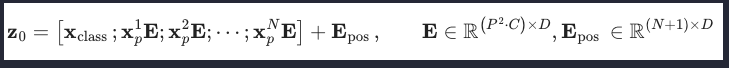

In [101]:
set_seeds()

# 1. Set patch size
patch_size = 16

# 2. Print shape of original image tensor and get the image dimensions
print(f"Image tensor shape: {image.shape}")
height, width = image.shape[1], image.shape[2]

# 3. Get image tensor and add batch dimension
x = image.unsqueeze(0)
print(f"Input image with batch dimension shape: {x.shape}")

# 4. Create patch embedding layer
patch_embedding_layer = PatchEmbedding(in_channels=3,
                                       patch_size=patch_size,
                                       embedding_dim=768)

# 5. Pass image through patch embedding layer
patch_embedding = patch_embedding_layer(x)
print(f"Patching embedding shape: {patch_embedding.shape}")

# 6. Create class token embedding
batch_size = patch_embedding.shape[0]
embedding_dimension = patch_embedding.shape[-1]
class_token = nn.Parameter(torch.ones(batch_size, 1, embedding_dimension),
                           requires_grad=True) # make sure it's learnable
print(f"Class token embedding shape: {class_token.shape}")

# 7. Prepend class token embedding to patch embedding
patch_embedding_class_token = torch.cat((class_token, patch_embedding), dim=1)
print(f"Patch embedding with class token shape: {patch_embedding_class_token.shape}")

# 8. Create position embedding
number_of_patches = int((height * width) / patch_size**2)
position_embedding = nn.Parameter(torch.ones(1, number_of_patches+1, embedding_dimension),
                                  requires_grad=True) # make sure it's learnable

# 9. Add position embedding to patch embedding with class token
patch_and_position_embedding = patch_embedding_class_token + position_embedding
print(f"Patch and position embedding shape: {patch_and_position_embedding.shape}")

Image tensor shape: torch.Size([3, 224, 224])
Input image with batch dimension shape: torch.Size([1, 3, 224, 224])
Patching embedding shape: torch.Size([1, 196, 768])
Class token embedding shape: torch.Size([1, 1, 768])
Patch embedding with class token shape: torch.Size([1, 197, 768])
Patch and position embedding shape: torch.Size([1, 197, 768])


#  5. Equation 2: Multi-Head Attention (MSA)

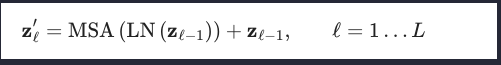

* Multi-Head Self Attention (MSA) - `torch.nn.MultiheadAttention()`, which part of a sequence should pay the most attention to when making predictions.
 - In our case, we have a series of embedded image patches, where one patch significantly relates to another patch.
 - We want our neural network (ViT) to learn this relationship/representation.
* Norm (LN or LayerNorm) - `torch.nn.LayerNorm()`, is a technique to normalize the distributions of intermediate layers. It enables smoother gradients, faster training and better generalization.
    - Normalization = make everything have the same mean and same standard deviation.

* Residual connection - add the input to output. It helps to prevent the vanishing gradient problem and allows training of deeper networks.


In [102]:
class MultiHeadSelfAttentionBlock(nn.Module):

    """Pre-normalized multi-head self-attention for a ViT encoder."""



    def __init__(self, embedding_dim=768, num_heads=12, attn_dropout=0.1):

        super().__init__()

        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

        self.multihead_attn = nn.MultiheadAttention(

            embed_dim=embedding_dim,

            num_heads=num_heads,

            dropout=attn_dropout,

            batch_first=True,

        )



    def forward(self, x):

        normalized_x = self.layer_norm(x)

        attn_output, _ = self.multihead_attn(

            query=normalized_x,

            key=normalized_x,

            value=normalized_x,

            need_weights=False,

        )

        return attn_output

In [103]:
# Create an instance of MSABlock
multihead_self_attention_block = MultiHeadSelfAttentionBlock(embedding_dim=768, # from Table 1
                                                             num_heads=12) # from Table 1

# Pass patch and position image embedding through MSABlock
patched_image_through_msa_block = multihead_self_attention_block(patch_and_position_embedding)
print(f"Input shape of MSA block: {patch_and_position_embedding.shape}")
print(f"Output shape MSA block: {patched_image_through_msa_block.shape}")

Input shape of MSA block: torch.Size([1, 197, 768])
Output shape MSA block: torch.Size([1, 197, 768])


# 6. Equation 3: Multilayer Perceptron (MLP)


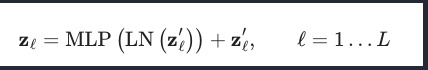


* **MLP** - Multi-Layer Perceptron, a neural network with at least one hidden layer. In the ViT paper, the MLP block consists of two linear layers with a GELU activation function in between.
 * MLP = a quite broad term for block with a series of layer(s), layers can be linear, convolutional, recurrent, etc. The MLP block in the ViT paper is a specific type of MLP block that consists of two linear layers with a GELU activation function in between.
 * Layers can mean: fully-connected layers, convolutional layers, recurrent layers, etc. In the case of the MLP block in the ViT paper, it refers to fully-connected layers.
 * Dropout - a regularization technique to prevent overfitting by randomly setting a fraction of the input units to 0 at each update during training time, which helps to prevent overfitting. In the ViT paper, dropout is applied after each linear layer in the MLP block.

 In pseudocode:

 ``` python
  #MLP block =
 x  = linear -> non-linear -> dropout -> linear -> dropout
 ```



In [104]:
# 1. Create a class that inherits from nn.Module
class MLPBlock(nn.Module):
    """Creates a layer normalized multilayer perceptron block ("MLP block" for short)."""
    # 2. Initialize the class with hyperparameters from Table 1 and Table 3
    def __init__(self,
                 embedding_dim:int=768, # Hidden Size D from Table 1 for ViT-Base
                 mlp_size:int=3072, # MLP size from Table 1 for ViT-Base
                 dropout:float=0.1): # Dropout from Table 3 for ViT-Base
        super().__init__()

        # 3. Create the Norm layer (LN)
        self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)

        # 4. Create the Multilayer perceptron (MLP) layer(s)
        self.mlp = nn.Sequential(
            nn.Linear(in_features=embedding_dim,
                      out_features=mlp_size),
            nn.GELU(), # "The MLP contains two layers with a GELU non-linearity (section 3.1)."
            nn.Dropout(p=dropout),
            nn.Linear(in_features=mlp_size, # needs to take same in_features as out_features of layer above
                      out_features=embedding_dim), # take back to embedding_dim
            nn.Dropout(p=dropout) # "Dropout, when used, is applied after every dense layer.."
        )

    # 5. Create a forward() method to pass the data through the layers
    def forward(self, x):
        x = self.layer_norm(x)
        x = self.mlp(x)
        
        return x

In [105]:
# Create an instance of MLPBlock
mlp_block = MLPBlock(embedding_dim=768, # from Table 1
                     mlp_size=3072, # from Table 1
                     dropout=0.1) # from Table 3

# Pass output of MSABlock through MLPBlock
patched_image_through_mlp_block = mlp_block(patched_image_through_msa_block)
print(f"Input shape of MLP block: {patched_image_through_msa_block.shape}")
print(f"Output shape MLP block: {patched_image_through_mlp_block.shape}")

Input shape of MLP block: torch.Size([1, 197, 768])
Output shape MLP block: torch.Size([1, 197, 768])



# 7. Create the Transformer Encoder
The Transformer Encoder is a combination of alternating blocks of MSA (Equation 2) and MLP (Equation 3).

And there are residual connections between each block.

* Encoder = turn a sequence into learnable representations
* Decoder = go from learn representations back to a sequence (e.g. for text generation, image generation, etc.)
* Residual connection = add a layer input to its subsequent output, this enables the creation of deeper networks (prevents weights from getting too small)


```python
# Transformer Encoder
x_input -> MSA_block -> [MSA_block_output + x_input] -> MLP_block -> [MLP_block_output + MSA_block_output + x_input] -> ...
```



### 7.1  Creating a Transformer Encoder by combining our custom made layers

In [106]:
class TransformerEncoderBlock(nn.Module):

    """Creates a pre-normalized Transformer encoder block."""



    def __init__(

        self,

        embedding_dim=768,

        num_heads=12,

        mlp_size=3072,

        mlp_dropout=0.1,

        attn_dropout=0,

    ):

        super().__init__()

        self.msa_block = MultiHeadSelfAttentionBlock(

            embedding_dim=embedding_dim,

            num_heads=num_heads,

            attn_dropout=attn_dropout,

        )

        self.mlp_block = MLPBlock(

            embedding_dim=embedding_dim,

            mlp_size=mlp_size,

            dropout=mlp_dropout,

        )



    def forward(self, x):

        x = x + self.msa_block(x)

        x = x + self.mlp_block(x)

        return x

In [107]:
# Create an instance of TransformerEncoderBlock
transformer_encoder_block = TransformerEncoderBlock()

# # Print an input and output summary of our Transformer Encoder (uncomment for full output)
summary(model=transformer_encoder_block,
        input_size=(1, 197, 768), # (batch_size, num_patches, embedding_dimension)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoderBlock (TransformerEncoderBlock)  [1, 197, 768]        [1, 197, 768]        --                   True
├─MultiHeadSelfAttentionBlock (msa_block)          [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─MultiheadAttention (multihead_attn)         --                   [1, 197, 768]        2,362,368            True
├─MLPBlock (mlp_block)                             [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─Sequential (mlp)                            [1, 197, 768]        [1, 197, 768]        --                   True
│    │    └─Linear (0)                     

### 7.2 Creating a Transformer Encoder with PyTorch's Transformer layers

In [108]:
# Create the same as above with torch.nn.TransformerEncoderLayer()
torch_transformer_encoder_layer = nn.TransformerEncoderLayer(d_model=768, # Hidden size D from Table 1 for ViT-Base
                                                             nhead=12, # Heads from Table 1 for ViT-Base
                                                             dim_feedforward=3072, # MLP size from Table 1 for ViT-Base
                                                             dropout=0.1, # Amount of dropout for dense layers from Table 3 for ViT-Base
                                                             activation="gelu", # GELU non-linear activation
                                                             batch_first=True, # Do our batches come first?
                                                             norm_first=True) # Normalize first or after MSA/MLP layers?

torch_transformer_encoder_layer

TransformerEncoderLayer(
  (self_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
  )
  (linear1): Linear(in_features=768, out_features=3072, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (linear2): Linear(in_features=3072, out_features=768, bias=True)
  (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (dropout1): Dropout(p=0.1, inplace=False)
  (dropout2): Dropout(p=0.1, inplace=False)
)

In [109]:
## Get the output of PyTorch's version of the Transformer Encoder (uncomment for full output)
summary(model=torch_transformer_encoder_layer,
        input_size=(1, 197, 768), # (batch_size, num_patches, embedding_dimension)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoderLayer (TransformerEncoderLayer)  [1, 197, 768]        [1, 197, 768]        --                   True
├─LayerNorm (norm1)                                [1, 197, 768]        [1, 197, 768]        1,536                True
├─MultiheadAttention (self_attn)                   [1, 197, 768]        [1, 197, 768]        2,362,368            True
├─Dropout (dropout1)                               [1, 197, 768]        [1, 197, 768]        --                   --
├─LayerNorm (norm2)                                [1, 197, 768]        [1, 197, 768]        1,536                True
├─Linear (linear1)                                 [1, 197, 768]        [1, 197, 3072]       2,362,368            True
├─Dropout (dropout)                                [1, 197, 3072]       [1, 197, 3072]       --                   --
├─Linear (linear2)                             

# 8. Putting it all together to create ViT



In [110]:
class ViT(nn.Module):

    """Vision Transformer with ViT-Base hyperparameters by default."""



    def __init__(

        self,

        img_size=224,

        in_channels=3,

        patch_size=16,

        num_transformer_layers=12,

        embedding_dim=768,

        mlp_size=3072,

        num_heads=12,

        attn_dropout=0,

        mlp_dropout=0.1,

        embedding_dropout=0.1,

        num_classes=1000,

    ):

        super().__init__()

        if img_size % patch_size != 0:

            raise ValueError(

                f"Image size {img_size} must be divisible by patch size {patch_size}."

            )



        self.num_patches = (img_size * img_size) // patch_size**2

        self.class_embedding = nn.Parameter(torch.randn(1, 1, embedding_dim))

        self.position_embedding = nn.Parameter(

            torch.randn(1, self.num_patches + 1, embedding_dim)

        )

        self.embedding_dropout = nn.Dropout(p=embedding_dropout)

        self.patch_embedding = PatchEmbedding(

            in_channels=in_channels,

            patch_size=patch_size,

            embedding_dim=embedding_dim,

        )

        self.transformer_encoder = nn.Sequential(

            *[

                TransformerEncoderBlock(

                    embedding_dim=embedding_dim,

                    num_heads=num_heads,

                    mlp_size=mlp_size,

                    mlp_dropout=mlp_dropout,

                    attn_dropout=attn_dropout,

                )

                for _ in range(num_transformer_layers)

            ]

        )

        self.classifier = nn.Sequential(

            nn.LayerNorm(normalized_shape=embedding_dim),

            nn.Linear(in_features=embedding_dim, out_features=num_classes),

        )



    def forward(self, x):

        batch_size = x.shape[0]

        class_token = self.class_embedding.expand(batch_size, -1, -1)

        x = self.patch_embedding(x)

        x = torch.cat((class_token, x), dim=1)



        if x.shape[1] != self.position_embedding.shape[1]:

            raise ValueError(

                f"Expected {self.num_patches} patches but received {x.shape[1] - 1}."

            )



        x = self.embedding_dropout(x + self.position_embedding)

        x = self.transformer_encoder(x)

        return self.classifier(x[:, 0])

In [111]:
# Example of creating the class embedding and expanding over a batch dimension
batch_size = 32
class_token_embedding_single = nn.Parameter(data=torch.randn(1, 1, 768)) # create a single learnable class token
class_token_embedding_expanded = class_token_embedding_single.expand(batch_size, -1, -1) # expand the single learnable class token across the batch dimension, "-1" means to "infer the dimension"

# Print out the change in shapes
print(f"Shape of class token embedding single: {class_token_embedding_single.shape}")
print(f"Shape of class token embedding expanded: {class_token_embedding_expanded.shape}")

Shape of class token embedding single: torch.Size([1, 1, 768])
Shape of class token embedding expanded: torch.Size([32, 1, 768])


In [112]:
set_seeds()

# Create a random tensor with same shape as a single image
random_image_tensor = torch.randn(1, 3, 224, 224) # (batch_size, color_channels, height, width)

# Create an instance of ViT with the number of classes we're working with (pizza, steak, sushi)
vit = ViT(num_classes=len(class_names))

# Pass the random image tensor to our ViT instance
vit(random_image_tensor)

tensor([[0.2525, 0.8748, 1.2374]], grad_fn=<AddmmBackward0>)

### 8.1 Getting a visual summary of our ViT model

In [113]:
from torchinfo import summary

# # Print a summary of our custom ViT model using torchinfo (uncomment for actual output)
summary(model=vit,
        input_size=(32, 3, 224, 224), # (batch_size, color_channels, height, width)
        #col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
ViT (ViT)                                                    [32, 3, 224, 224]    [32, 3]              152,064              True
├─PatchEmbedding (patch_embedding)                           [32, 3, 224, 224]    [32, 196, 768]       --                   True
│    └─Conv2d (patcher)                                      [32, 3, 224, 224]    [32, 768, 14, 14]    590,592              True
│    └─Flatten (flatten)                                     [32, 768, 14, 14]    [32, 768, 196]       --                   --
├─Dropout (embedding_dropout)                                [32, 197, 768]       [32, 197, 768]       --                   --
├─Sequential (transformer_encoder)                           [32, 197, 768]       [32, 197, 768]       --                   True
│    └─TransformerEncoderBlock (0)                           [32, 197, 768]       [32, 197, 768]

# 9. Setting up training code for our ViT model

### 9.1 Create an optimizer

The paper uses the Adam optimizer (section 4, Training & fine-tuning) with $B1$ value of 0.9 and $B2$ value of 0.999. The learning rate is set to 3e-3 and the weight decay is set to 0.1.

Weight decay is a regularization technique that adds a penalty to the loss function based on the magnitude of the model's weights. This helps to prevent overfitting by discouraging the model from learning overly complex patterns in the training data.

Regularization Technique = Prevents overfitting.

In [114]:


# Setup the optimizer to optimize our ViT model parameters using hyperparameters from the ViT paper
optimizer = torch.optim.Adam(params=vit.parameters(),
                             lr=1e-3, # Base LR from Table 3 for ViT-* ImageNet-1k
                             betas=(0.9, 0.999), # default values but also mentioned in ViT paper section 4.1 (Training & Fine-tuning)
                             weight_decay=0.1) # from the ViT paper section 4.1 (Training & Fine-tuning) and Table 3 for ViT-* ImageNet-1k





### 9.2 Create a loss function

The ViT paper does not actually mention what loss function they used.

So since it's mult-class classification problem, we can use `torch.nn.CrossEntropyLoss()` which is a common loss function for multi-class classification problems.

In [115]:
# Setup the loss function for multi-class classification
loss_fn = torch.nn.CrossEntropyLoss()

### 9.3 Training the ViT Model

In [116]:
from going_modular.going_modular import engine

set_seeds()

optimizer = torch.optim.AdamW(
    params=vit.parameters(),
    lr=1e-4,
    betas=(0.9, 0.999),
    weight_decay=0.01
)

loss_fn = torch.nn.CrossEntropyLoss()

results = engine.train(
    model=vit,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=10,
    device=device
)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.2044 | train_acc: 0.3227 | test_loss: 1.1164 | test_acc: 0.3333
Epoch: 2 | train_loss: 1.1041 | train_acc: 0.3860 | test_loss: 1.0519 | test_acc: 0.4117
Epoch: 3 | train_loss: 1.0210 | train_acc: 0.4823 | test_loss: 1.0199 | test_acc: 0.4633
Epoch: 4 | train_loss: 0.9731 | train_acc: 0.5043 | test_loss: 0.9981 | test_acc: 0.4833
Epoch: 5 | train_loss: 0.9208 | train_acc: 0.5420 | test_loss: 0.9698 | test_acc: 0.5250
Epoch: 6 | train_loss: 0.8956 | train_acc: 0.5713 | test_loss: 0.9461 | test_acc: 0.5200
Epoch: 7 | train_loss: 0.8616 | train_acc: 0.5987 | test_loss: 0.8910 | test_acc: 0.5633
Epoch: 8 | train_loss: 0.7986 | train_acc: 0.6270 | test_loss: 0.8392 | test_acc: 0.6367
Epoch: 9 | train_loss: 0.7521 | train_acc: 0.6580 | test_loss: 0.8084 | test_acc: 0.6600
Epoch: 10 | train_loss: 0.7511 | train_acc: 0.6740 | test_loss: 0.9191 | test_acc: 0.5550


### 9.4 What our training setup is missing

How is our training setup different from the ViT paper?

We've replicated model archiretecture correctly.

But what was different between aour training procedure (to get such poor results)
and the ViT paper's training procedure to get such great results?

The main things our training implementation is missing:

Prevent Underfitting:
* Data - our setup uses far less data (225 vs millions)


Prevent overfitting:
* Learning rate warmup - start with a low learning rate and increase to a base LR
* Learning rate decay - as your model gets closer to convergence, start to lower the learning rate.
* Gradient clipping - prevent gradients from exploding (getting too large) and causing the model to diverge (not learn).

Search "pyTorch [technique name]" for implementation details.



### 9.5 Plotting loss curves for our model

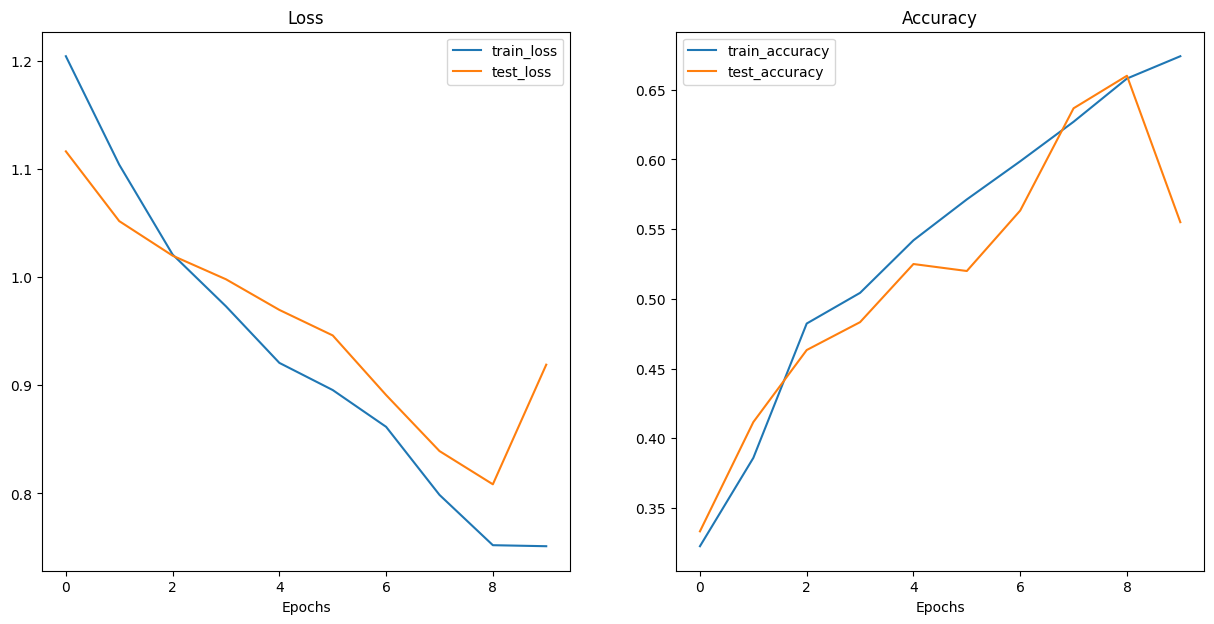

In [117]:
from helper_functions import plot_loss_curves

plot_loss_curves(results)


## 10. Using a pretrained ViT model from PyTorch's `torchvision.models` library

Generally in deep learning, using a pretrained model can save time and computational resources, as well as improve performance, especially when you have limited data.

### 10.1 Why use a pretrained model?
* Sometimes data is limited
* Limited training resources (time, money, compute)
* Get better results faster (sometimes)...



In [118]:
# The following code checks the versions of PyTorch and Torchvision installed in your environment. This is useful for ensuring compatibility with the code and libraries you are using.
import torch
import torchvision
print(torch.__version__)
print(torchvision.__version__)


2.11.0+cu128
0.26.0+cu128


In [119]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### 10.2 Prepare a pretrained ViT for use with our dataset (turn it into a feature extractor)

When using a pretrained model ,you want to make sure your data is formatted in the same way that the model was trained on. This means using the same image size, normalization, and data augmentation techniques as the original model.

In [120]:
# Get pretrained weights from torchvision's ViT model
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT # "DEFAULT" = best available weights for the model


# Setup a ViT model instance with pretrained weights
pretrained_vit = torchvision.models.vit_b_16(weights=pretrained_vit_weights).to(device) # send to device

# Freeze the base parameters
for parameter in pretrained_vit.parameters():
    parameter.requires_grad = False

# udate the classifier head to match the number of classes in our dataset
set_seeds()
pretrained_vit.heads = nn.Linear(in_features=768, # from Table 1
                                 out_features=len(class_names)) # number of classes in our dataset  


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 217MB/s]  


In [121]:
from torchinfo import summary

summary(model=pretrained_vit,
        input_size=(1, 3, 224, 224), # (batch_size, color_channels, height, width)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]     )

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224]     [1, 3]               768                  Partial
├─Conv2d (conv_proj)                                         [1, 3, 224, 224]     [1, 768, 14, 14]     (590,592)            False
├─Encoder (encoder)                                          [1, 197, 768]        [1, 197, 768]        151,296              False
│    └─Dropout (dropout)                                     [1, 197, 768]        [1, 197, 768]        --                   --
│    └─Sequential (layers)                                   [1, 197, 768]        [1, 197, 768]        --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 768]        [1, 197, 768]        (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 768]        [1, 1

### 10.3 Preparing data for a pretrained ViT model

When using a pretrained model ,you want to make sure your data is formatted in the same way that the model was trained on. This means using the same image size, normalization, and data augmentation techniques as the original model.

In [122]:
# get automatic transforms from the pretrained weights
pretrained_vit_transforms = pretrained_vit_weights.transforms()

pretrained_vit_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [123]:
# Recreate loaders with the pretrained ViT transforms and the same subset
pretrained_vit_train_dataloader, pretrained_vit_test_dataloader, class_names = create_percentage_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=pretrained_vit_transforms,
    batch_size=BATCH_SIZE,
    train_percentage=TRAIN_PERCENTAGE,
    seed=DATA_SEED,
    num_workers=2,
)

Training with 3000/3000 images (100% requested): clear=1000, heavily_occluded=1000, partially_occluded=1000
Evaluating with all 600 test images


## 10.4 Train feature extractor ViT model

In [124]:
from going_modular.going_modular import engine




# Create an optimizer and loss function for the pretrained ViT model
optimizer = torch.optim.AdamW(
    params=pretrained_vit.parameters(), 
    lr=1e-3,
    
)

loss_fn = torch.nn.CrossEntropyLoss()

# Create a train the classifier head of pretrained ViT
set_seeds()
results_pretrained_vit = engine.train(
    model=pretrained_vit,
    train_dataloader=pretrained_vit_train_dataloader,
    test_dataloader=pretrained_vit_test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=10,
    device=device
)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.6500 | train_acc: 0.7453 | test_loss: 0.4659 | test_acc: 0.8317
Epoch: 2 | train_loss: 0.3712 | train_acc: 0.8710 | test_loss: 0.3719 | test_acc: 0.8583
Epoch: 3 | train_loss: 0.2863 | train_acc: 0.9063 | test_loss: 0.3302 | test_acc: 0.8700
Epoch: 4 | train_loss: 0.2360 | train_acc: 0.9330 | test_loss: 0.2924 | test_acc: 0.8833
Epoch: 5 | train_loss: 0.2009 | train_acc: 0.9443 | test_loss: 0.2807 | test_acc: 0.8817
Epoch: 6 | train_loss: 0.1759 | train_acc: 0.9523 | test_loss: 0.2692 | test_acc: 0.8900
Epoch: 7 | train_loss: 0.1575 | train_acc: 0.9597 | test_loss: 0.2580 | test_acc: 0.8950
Epoch: 8 | train_loss: 0.1441 | train_acc: 0.9620 | test_loss: 0.2539 | test_acc: 0.8833
Epoch: 9 | train_loss: 0.1293 | train_acc: 0.9680 | test_loss: 0.2422 | test_acc: 0.8900
Epoch: 10 | train_loss: 0.1179 | train_acc: 0.9740 | test_loss: 0.2273 | test_acc: 0.9050


In [125]:
# Evaluate every test image, not just one example.

num_classes = len(class_names)

confusion_matrix = torch.zeros((num_classes, num_classes), dtype=torch.int64)



pretrained_vit.eval()

with torch.inference_mode():

    for images, labels in pretrained_vit_test_dataloader:

        predictions = pretrained_vit(images.to(device)).argmax(dim=1).cpu()

        positions = labels * num_classes + predictions

        confusion_matrix += torch.bincount(

            positions,

            minlength=num_classes * num_classes,

        ).reshape(num_classes, num_classes)



print("Rows = actual class, columns = predicted class")

print("Class order:", class_names)

print(confusion_matrix)

print()



for class_index, class_name in enumerate(class_names):

    correct = confusion_matrix[class_index, class_index].item()

    total = confusion_matrix[class_index].sum().item()

    print(f"{class_name}: {correct}/{total} ({correct / total:.1%})")



overall_accuracy = confusion_matrix.diag().sum().item() / confusion_matrix.sum().item()

print(f"Overall test accuracy: {overall_accuracy:.1%}")

Rows = actual class, columns = predicted class
Class order: ['clear', 'heavily_occluded', 'partially_occluded']
tensor([[187,   2,  11],
        [  5, 174,  21],
        [  5,  13, 182]])

clear: 187/200 (93.5%)
heavily_occluded: 174/200 (87.0%)
partially_occluded: 182/200 (91.0%)
Overall test accuracy: 90.5%


## 10.5 Plotting loss curves for our pretrained ViT model






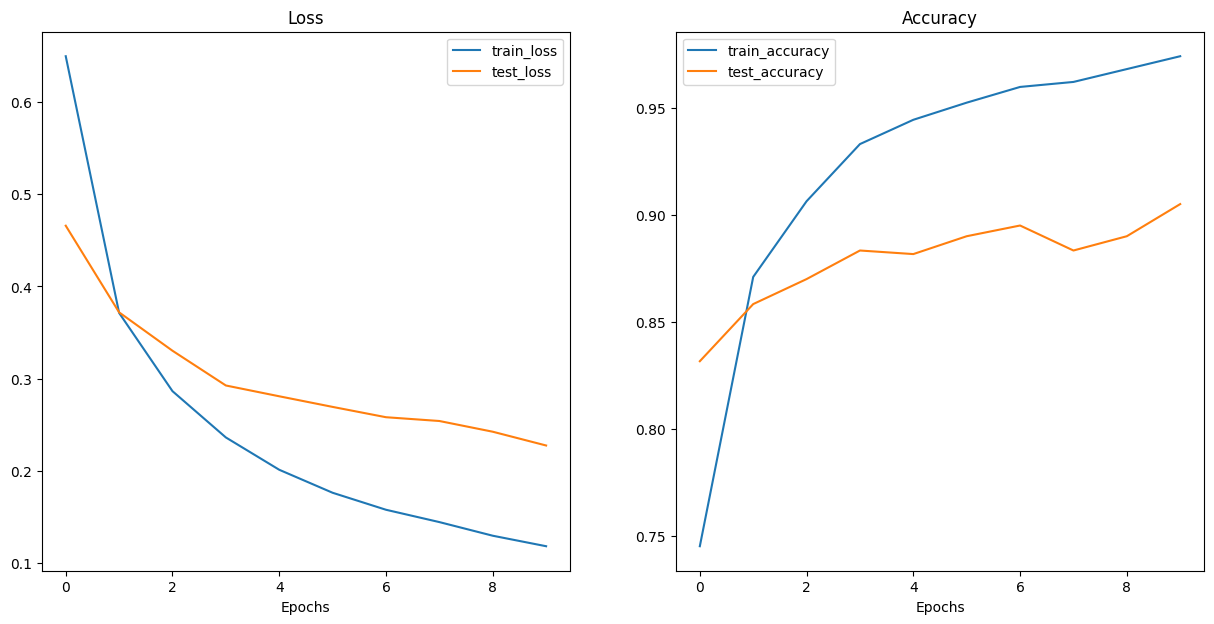

In [126]:
from helper_functions import plot_loss_curves

plot_loss_curves(results_pretrained_vit)

## 10.6 Save best performing pretrained ViT model


Now we got a model that performs quite well, how about we save it to file and then check it's filesize.

We want to check the filesize because if we wanted to deploy a model to say a website/mobile app, we would want to make sure the model is small enough to be downloaded and used by the end user.

```python
import torch

# Assuming `best_pretrained_vit_model` is your best performing pretrained ViT model
torch.save(best_pretrained_vit_model.state_dict(), "best_pretrained_vit_model.pth")
```

In [127]:
# Save the trained model permanently on Google Drive.

from going_modular.going_modular import utils



MODEL_DIR = PROJECT_DIR / "models"

MODEL_NAME = "pretrained_vit_picksense.pth"



utils.save_model(

    model=pretrained_vit,

    target_dir=MODEL_DIR,

    model_name=MODEL_NAME,

)

[INFO] Saving model to: /content/drive/MyDrive/PickSense/models/pretrained_vit_picksense.pth


In [128]:
from pathlib import Path



saved_model_path = MODEL_DIR / MODEL_NAME

pretrained_vit_model_size = saved_model_path.stat().st_size / (1024 * 1024)

print("Saved model:", saved_model_path)

print(f"Pretrained ViT model size: {pretrained_vit_model_size:.1f} MB")

Saved model: /content/drive/MyDrive/PickSense/models/pretrained_vit_picksense.pth
Pretrained ViT model size: 327.4 MB


## 11. Make predictions on a custom image

In [129]:
from pathlib import Path

list(Path("going_modular/going_modular").glob("*.py"))

[PosixPath('going_modular/going_modular/engine.py'),
 PosixPath('going_modular/going_modular/train.py'),
 PosixPath('going_modular/going_modular/data_setup.py'),
 PosixPath('going_modular/going_modular/utils.py'),
 PosixPath('going_modular/going_modular/predictions.py'),
 PosixPath('going_modular/going_modular/model_builder.py')]

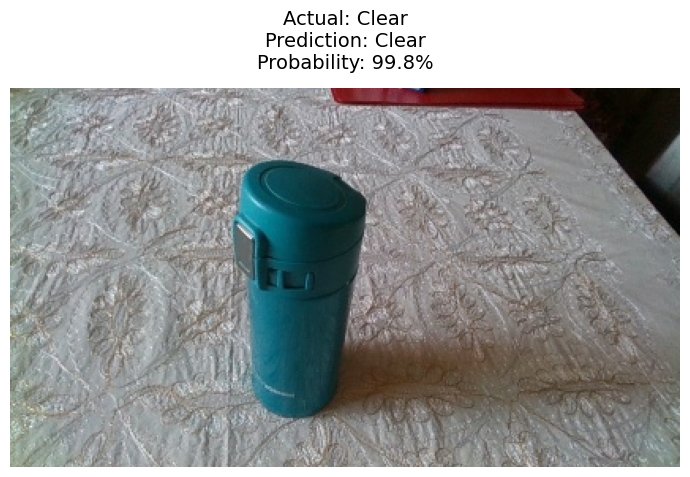

In [130]:
import random
from PIL import Image

# The training loader uses Subset, whose .dataset is the original ImageFolder.
train_subset = pretrained_vit_train_dataloader.dataset
class_names = train_subset.dataset.classes

# Select a random test image from the requested class each time this cell runs.
sample_class = "clear"  # clear, partially_occluded, or heavily_occluded
sample_directory = TEST_DIR / sample_class
candidate_images = [
    path
    for path in sorted(sample_directory.iterdir())
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
]

if not candidate_images:
    raise FileNotFoundError(
        f"No supported images were found in {sample_directory}."
    )

custom_image_path = random.choice(candidate_images)
print(f"Selected image: {custom_image_path.name}")

# The parent folder contains the true class label.
actual_class = custom_image_path.parent.name

if actual_class not in class_names:
    raise ValueError(
        f"Unknown test label '{actual_class}'. Expected one of {class_names}."
    )

# Load and transform the image exactly as during model training.
image = Image.open(custom_image_path).convert("RGB")
image_tensor = pretrained_vit_transforms(image).unsqueeze(0).to(device)

# Reuse the trained model.
model = pretrained_vit
model.eval()

with torch.inference_mode():
    logits = model(image_tensor)
    probabilities = torch.softmax(logits, dim=1)
    predicted_index = torch.argmax(probabilities, dim=1).item()

predicted_class = class_names[predicted_index]
predicted_probability = probabilities[0, predicted_index].item()

# Convert dataset labels into presentation-friendly labels.
def presentation_label(class_name):
    return class_name.replace("_", " ").title()

actual_display = presentation_label(actual_class)
prediction_display = presentation_label(predicted_class)

# Presentation output.
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(image)
ax.set_title(
    f"Actual: {actual_display}\n"
    f"Prediction: {prediction_display}\n"
    f"Probability: {predicted_probability:.1%}",
    fontsize=14,
    pad=14,
)
ax.axis("off")
plt.tight_layout()
plt.show()